<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [1]:


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [2]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


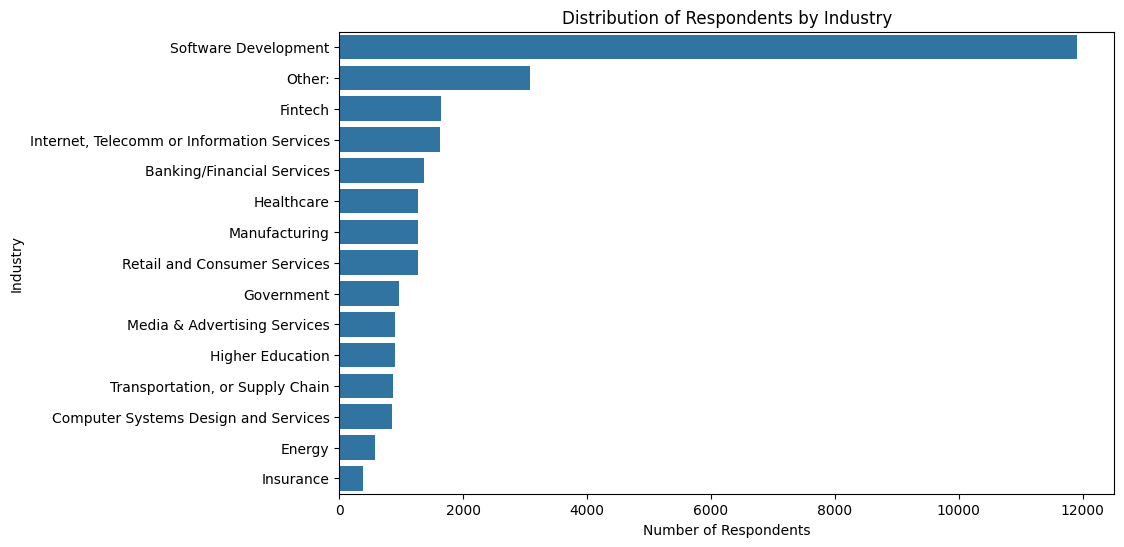

Industry distribution:
Industry
Software Development                          11918
Other:                                         3077
Fintech                                        1641
Internet, Telecomm or Information Services     1629
Banking/Financial Services                     1371
Healthcare                                     1277
Manufacturing                                  1265
Retail and Consumer Services                   1264
Government                                      962
Media & Advertising Services                    894
Higher Education                                890
Transportation, or Supply Chain                 859
Computer Systems Design and Services            844
Energy                                          578
Insurance                                       389
Name: count, dtype: int64


In [3]:
##Write your code here
# Step 2: Plot the Distribution of Industry
plt.figure(figsize=(10, 6))
industry_counts = df['Industry'].value_counts()
sns.barplot(x=industry_counts.values, y=industry_counts.index)
plt.title('Distribution of Respondents by Industry')
plt.xlabel('Number of Respondents')
plt.ylabel('Industry')
plt.show()

# Display the counts
print("Industry distribution:")
print(industry_counts)

<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [4]:
##Write your code here

# Step 3: Identify High Compensation Outliers
print("Basic Statistics for ConvertedCompYearly:")
print(df['ConvertedCompYearly'].describe())

# Calculate mean and standard deviation
mean_comp = df['ConvertedCompYearly'].mean()
std_comp = df['ConvertedCompYearly'].std()

# Identify outliers (3 standard deviations above the mean)
threshold = mean_comp + 3 * std_comp
high_outliers = df[df['ConvertedCompYearly'] > threshold]

print(f"\nMean: ${mean_comp:,.2f}")
print(f"Standard Deviation: ${std_comp:,.2f}")
print(f"Threshold (3 std above mean): ${threshold:,.2f}")
print(f"Number of high compensation outliers: {len(high_outliers)}")
print(f"Outliers:")
print(high_outliers[['ConvertedCompYearly', 'Age']].head())




Basic Statistics for ConvertedCompYearly:
count    2.343500e+04
mean     8.615529e+04
std      1.867570e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.500000e+04
75%      1.079715e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64

Mean: $86,155.29
Standard Deviation: $186,756.97
Threshold (3 std above mean): $646,426.21
Number of high compensation outliers: 89
Outliers:
      ConvertedCompYearly              Age
529              650000.0  25-34 years old
828             1000000.0  35-44 years old
1932             945000.0  25-34 years old
2171             750000.0  35-44 years old
2187            2000000.0  35-44 years old


<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


Interquartile Range (IQR): $75,259.50
Lower Bound: $-80,177.25
Upper Bound: $220,860.75
Number of outliers detected: 978


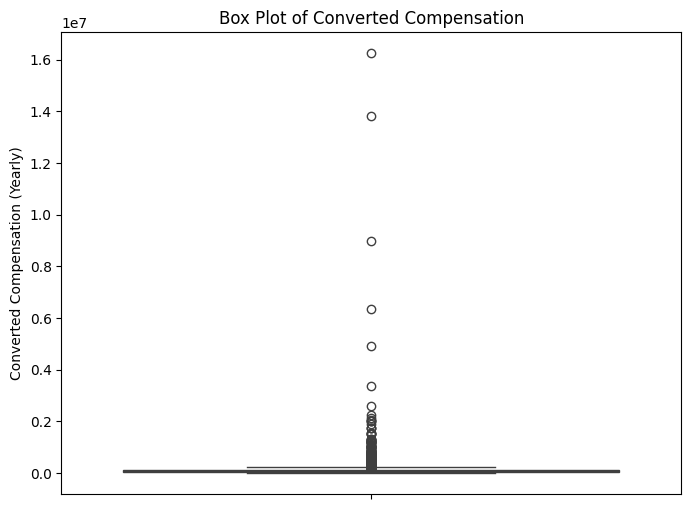

In [5]:
##Write your code here
# Step 4: Detect Outliers in Compensation
# Calculate Q1, Q3, and IQR
Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)
IQR = Q3 - Q1

# Calculate lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['ConvertedCompYearly'] < lower_bound) | (df['ConvertedCompYearly'] > upper_bound)]
print(f"Interquartile Range (IQR): ${IQR:,.2f}")
print(f"Lower Bound: ${lower_bound:,.2f}")
print(f"Upper Bound: ${upper_bound:,.2f}")
print(f"Number of outliers detected: {len(outliers)}")

# Create box plot to visualize outliers
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['ConvertedCompYearly'])
plt.title('Box Plot of Converted Compensation')
plt.ylabel('Converted Compensation (Yearly)')
plt.show()

<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


Original dataset size: 65437
Dataset size after removing outliers: 22457
Number of rows removed: 42980


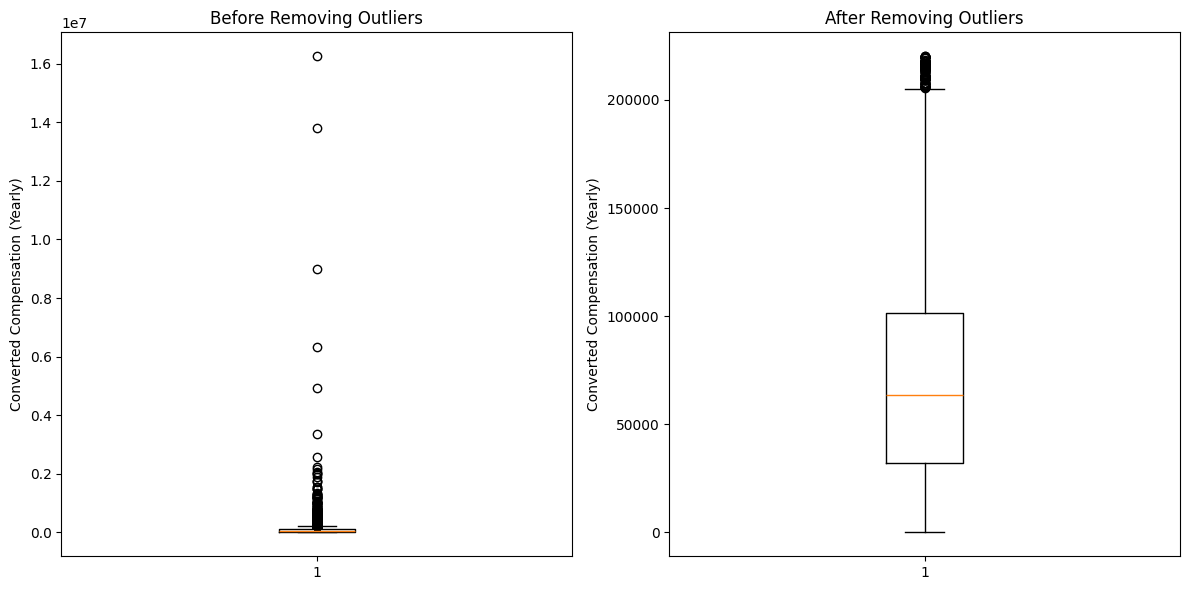


First 5 records of the cleaned dataset:


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
72,73,I am a developer by profession,18-24 years old,"Employed, full-time;Student, full-time;Indepen...","Hybrid (some remote, some in-person)",Apples,Hobby;School or academic work;Professional dev...,"Secondary school (e.g. American high school, G...",On the job training;Other online resources (e....,Technical documentation;Blogs;Written Tutorial...,...,65.0,100.0,100.0,100.0,50.0,90.0,Too long,Easy,7322.0,10.0
374,375,"I am not primarily a developer, but I write co...",25-34 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby;School or academic work;Professional dev...,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",Books / Physical media;Colleague;On the job tr...,Written Tutorials;Stack Overflow;Written-based...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Neither easy nor difficult,30074.0,NaN
379,380,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Bootstrapping a business,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Other online resources ...,Technical documentation;Books;Social Media;Wri...,...,0.0,0.0,0.0,0.0,0.0,0.0,Too long,Difficult,91295.0,10.0
385,386,I am a developer by profession,35-44 years old,"Independent contractor, freelancer, or self-em...",Remote,Apples,Hobby,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;On the job training;Oth...,Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,53703.0,NaN
389,390,I am a developer by profession,25-34 years old,"Employed, full-time;Student, part-time",Remote,Apples,Hobby;School or academic work,Some college/university study without earning ...,Books / Physical media;Colleague;On the job tr...,Written Tutorials;Stack Overflow;Coding sessio...,...,20.0,30.0,5.0,20.0,10.0,5.0,Too long,Easy,110000.0,10.0


In [8]:
# Step 5: Remove Outliers and Create a New DataFrame (with improved visualization)
# Using IQR method to remove outliers
df_no_outliers = df[(df['ConvertedCompYearly'] >= lower_bound) & (df['ConvertedCompYearly'] <= upper_bound)]

print(f"Original dataset size: {len(df)}")
print(f"Dataset size after removing outliers: {len(df_no_outliers)}")
print(f"Number of rows removed: {len(df) - len(df_no_outliers)}")

# Create side-by-side box plots to visualize the effect of outlier removal
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Before removing outliers
if len(df['ConvertedCompYearly'].dropna()) > 0:
    ax1.boxplot(df['ConvertedCompYearly'].dropna())
    ax1.set_title('Before Removing Outliers')
    ax1.set_ylabel('Converted Compensation (Yearly)')
else:
    ax1.text(0.5, 0.5, 'No data to display', ha='center', va='center', transform=ax1.transAxes)
    ax1.set_title('Before Removing Outliers')

# After removing outliers
if len(df_no_outliers['ConvertedCompYearly'].dropna()) > 0:
    ax2.boxplot(df_no_outliers['ConvertedCompYearly'].dropna())
    ax2.set_title('After Removing Outliers')
    ax2.set_ylabel('Converted Compensation (Yearly)')
else:
    ax2.text(0.5, 0.5, 'No data to display', ha='center', va='center', transform=ax2.transAxes)
    ax2.set_title('After Removing Outliers')

plt.tight_layout()
plt.show()

# Display the first few records of the new dataframe
print("\nFirst 5 records of the cleaned dataset:")
df_no_outliers.head()

<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


Age distribution:
Age
18-24 years old       14098
25-34 years old       23911
35-44 years old       14942
45-54 years old        6249
55-64 years old        2575
65 years or older       772
Prefer not to say       322
Under 18 years old     2568
Name: count, dtype: int64

Correlation Matrix:
                     ResponseId  CompTotal   WorkExp  JobSatPoints_1  \
ResponseId             1.000000  -0.000000  0.011955       -0.002406   
CompTotal             -0.000000   0.000000  0.028766       -0.004891   
WorkExp                0.011955   0.028766  1.000000       -0.026490   
JobSatPoints_1        -0.002406  -0.004891 -0.026490        1.000000   
JobSatPoints_4        -0.015738  -0.002719 -0.067241        0.445710   
JobSatPoints_5        -0.014197  -0.003033 -0.104525        0.633765   
JobSatPoints_6        -0.001908  -0.006311 -0.065352        0.618618   
JobSatPoints_7         0.001843  -0.005893 -0.101461        0.603157   
JobSatPoints_8        -0.002968  -0.004585 -0.046958       

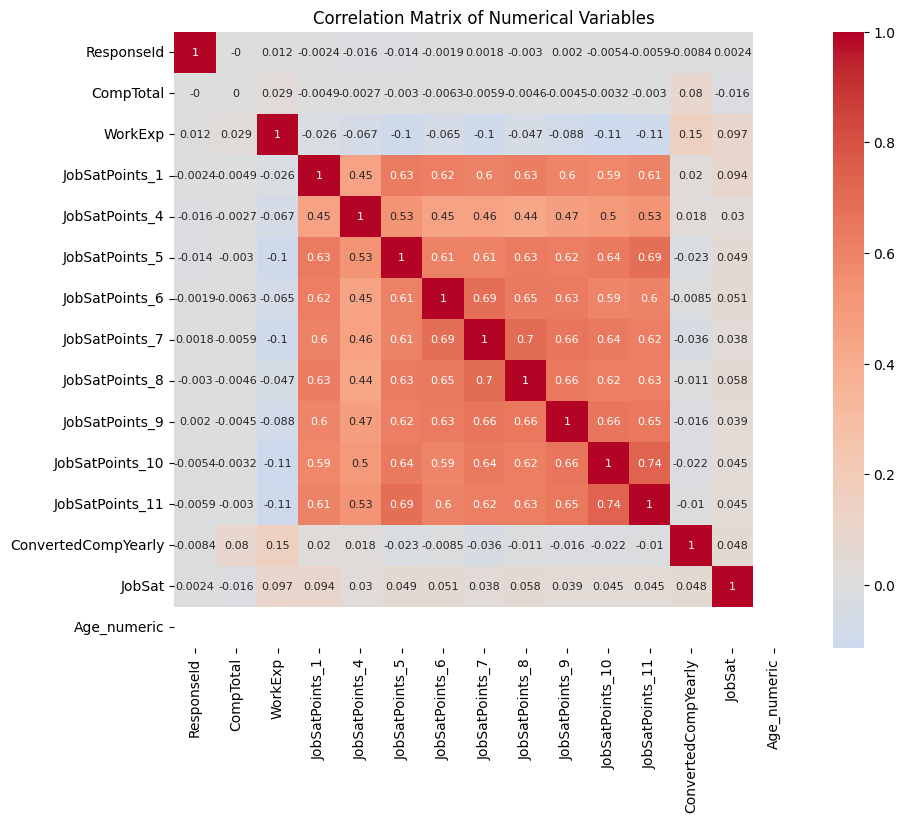


Correlations with Age (transformed):
ResponseId            NaN
CompTotal             NaN
WorkExp               NaN
JobSatPoints_1        NaN
JobSatPoints_4        NaN
JobSatPoints_5        NaN
JobSatPoints_6        NaN
JobSatPoints_7        NaN
JobSatPoints_8        NaN
JobSatPoints_9        NaN
JobSatPoints_10       NaN
JobSatPoints_11       NaN
ConvertedCompYearly   NaN
JobSat                NaN
Name: Age_numeric, dtype: float64


In [15]:


# 1. Display initial distribution
print("Age distribution:")
print(df['Age'].value_counts().sort_index())

# 2. Create a mapping for age ranges to numeric values
# Using midpoints for the ranges to represent the data more accurately
age_mapping = {
    'Under 18': 15,
    '18-24': 21,
    '25-34': 30,
    '35-44': 40,
    '45-54': 50,
    '55-64': 60,
    '65 years or older': 70
}

# Apply the mapping to create a numeric age column
df['Age_numeric'] = df['Age'].map(age_mapping)

# 3. Select only numerical columns for correlation analysis
numeric_columns = df.select_dtypes(include=['number']).columns.tolist()

# Ensure we are correlating relevant numeric data
if 'Age' in numeric_columns:
    numeric_columns.remove('Age')

# 4. Calculate correlation matrix
correlation_matrix = df[numeric_columns].corr()

# Display the correlation matrix text
print("\nCorrelation Matrix:")
print(correlation_matrix)

# 5. Visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0, 
            annot_kws={"size": 8}) 
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

# 6. Display correlations with Age_numeric
print("\nCorrelations with Age (transformed):")
# Fixed: Sorting the Series directly without the 'by' parameter
age_correlations = correlation_matrix['Age_numeric'].sort_values(ascending=False)

# Optional: Drop the self-correlation (Age_numeric vs Age_numeric) for clarity
print(age_correlations.drop('Age_numeric', errors='ignore'))

<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
